<a href="https://colab.research.google.com/github/useDeep/learn_pytorch/blob/main/03_pytorch_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pytorch Computer Vision

## 0. Computer Vision libraries in Pytorch

- `torchvision.datasets` - get datasets and data loading functions for computer vision here
- `torchvision.models` - get pretrained computer vision models that can leveraged for own problems
- `torchvision.transforms` - functions for manipulating vision data (images) to be suitable for with an ML model

- `torch.utils.data.Dataset` - Base dataset class for Pytorch
- `torch.utils.data.DataLoader` - Creates a Python iterable over a dataset

In [1]:
# Import Pytorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Import matplotlib
import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu128
0.25.0+cu128


## 1. Getting a dataset

Using FashionMNIST here from torchvision.datasets

In [2]:
# Setup training data
train_data= datasets.FashionMNIST(
    root= "data",   # where to download data to?
    train= True,    # True -> training data ; False -> test data
    download= True,
    transform= ToTensor(),    # transform the data to...? [ ToTensor() from torchvision.transforms.ToTensor() ]
    target_transform= None    # transaform the labels/ targets to...?
)

test_data= datasets.FashionMNIST(
    root= "data",
    train= False,
    download= True,
    transform= ToTensor(),
    target_transform= None
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 179kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.21MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.5MB/s]


In [3]:
len(train_data), len(test_data)

(60000, 10000)

In [4]:
# first training example
image, label= train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [5]:
class_names= train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
class_to_idx= train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [7]:
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [8]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [9]:
image.shape, label    # (torch.Size([1, 28, 28]), 9) -> [c, h, w], int label

(torch.Size([1, 28, 28]), 9)

### 1.2 Visualize the data

Text(0.5, 1.0, '9')

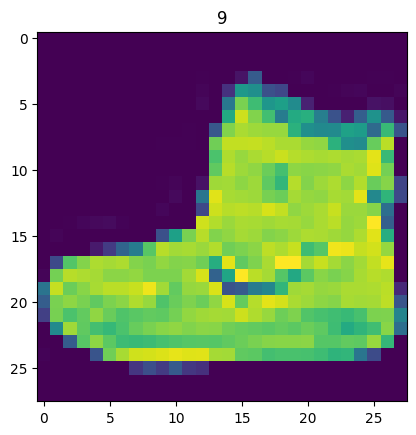

In [10]:
plt.imshow(image.squeeze())
plt.title(label)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

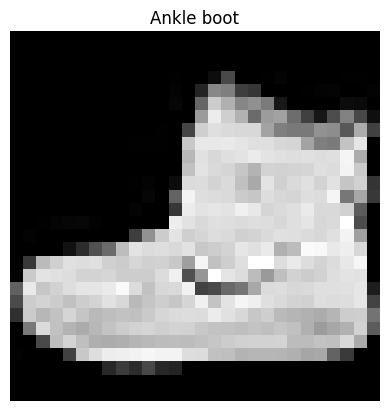

In [11]:
plt.imshow(image.squeeze(), cmap= "gray")
plt.title(class_names[label])
plt.axis(False)

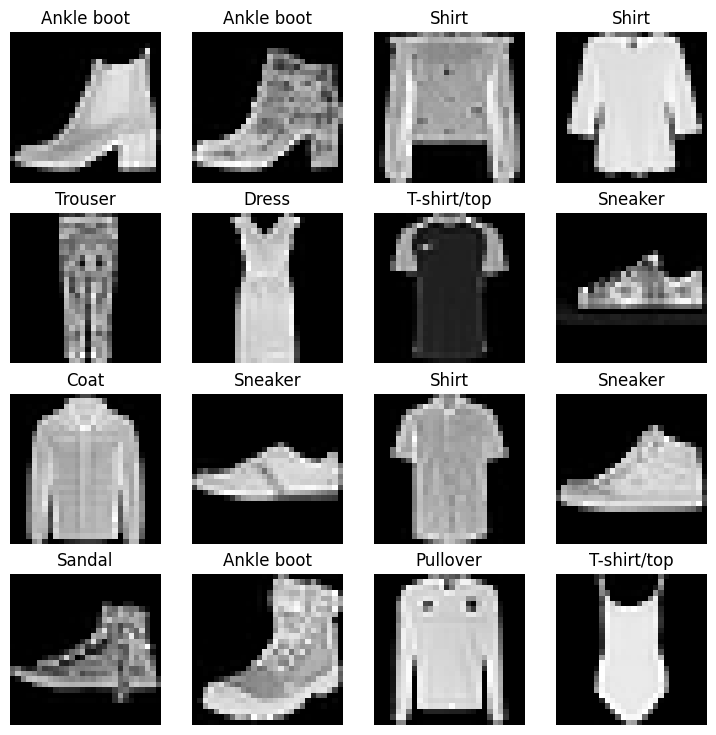

In [12]:
torch.manual_seed(77)
fig= plt.figure(figsize= (9, 9))
rows, cols= 4, 4
for i in range(1, rows* cols+ 1):
  random_idx= torch.randint(0, len(train_data), size=[1]).item()
  image, label= train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(image.squeeze(), cmap= "gray")
  plt.title(class_names[label])
  plt.axis(False)

## 2. Prepare DataLoader

Turn the data into batches (or mini-batches) because:
1. It is computationally efficeint as the computer hardware may not be able to look (store in memory) at 60000 images at once. So, breaking it down into 32 images at a time (batch size of 32).
2. It gives the neural network more chances to update it's gradients per epoch.

In [13]:
60000/32

1875.0

In [14]:
from torch.utils.data import DataLoader

# Setup the batsize hyperparameter
BATCH_SIZE= 32

# Turn datasets into iterables (batches)
train_dataloader= DataLoader(dataset= train_data,
                             batch_size= BATCH_SIZE,
                             shuffle= True)

test_dataloader= DataLoader(dataset= test_data,
                            batch_size= BATCH_SIZE,
                            shuffle= False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7bc03d04d1c0>,
 <torch.utils.data.dataloader.DataLoader at 0x7bc03cff0110>)

In [15]:
len(train_dataloader), len(test_dataloader)

(1875, 313)

In [16]:
60000/32, 10000/32

(1875.0, 312.5)

In [17]:
next(iter(train_dataloader))

[tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         ...,
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ..

In [18]:
train_features_batch, train_labels_batch= next(iter(train_dataloader))

train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image Size: torch.Size([1, 28, 28])
Label: 2, Label Size: torch.Size([])


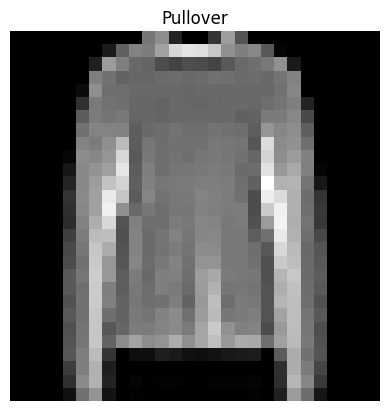

In [19]:
torch.manual_seed(77)
random_idx= torch.randint(1, len(train_features_batch), size=[1]).item()
img, label= train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap= 'gray')
plt.title(class_names[label])
plt.axis(False)
print(f"Image Size: {img.shape}")
print(f"Label: {label}, Label Size: {label.shape}")

## 3. Model 0: Building a baseline model

When starting to build a series of machine learning modelling experiments, it's best practice to start with a baseline model.

In [20]:
# Create a flatten layer
flatten_model= nn.Flatten()

# Get a single sample
x= train_features_batch[0]
x.shape   # -> [color_channels, height, weight]

torch.Size([1, 28, 28])

In [21]:
output= flatten_model(x)    # Perform forward pass
output.shape    # -> [color_channel, height * weight]

torch.Size([1, 784])

In [22]:
from torch.nn.modules import flatten
output= flatten_model(output)
output.shape

torch.Size([1, 784])

In [23]:
output.squeeze()
output.shape

torch.Size([1, 784])

In [24]:
class FashionMNISTV0(nn.Module):
  def __init__(self, input_shape: int, hidde_units: int, output_shape: int):
    super().__init__()
    self.layer_stack= nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= input_shape, out_features= hidde_units),
        nn.Linear(in_features= hidde_units, out_features= output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)


In [25]:
torch.manual_seed(77)

model_0= FashionMNISTV0(
    input_shape= 784,   # 28 * 28
    hidde_units= 10,
    output_shape= len(class_names)
)

model_0

FashionMNISTV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [26]:
dummy_x= torch.rand([1, 1, 28, 28])
model_0(dummy_x)

tensor([[-0.1077, -0.2435,  0.0373, -0.3531,  0.0730, -0.1176,  0.1160, -0.0771,
          0.4625, -0.2019]], grad_fn=<AddmmBackward0>)

### 3.1 Setup loss, optimizer and accuracy

- Loss function: since, it's multi-class classfication, the loss function will be nn.CrossEntropyLoss()
- Optimizer: torch.optim.SGD()
- Evaluation metric: Since, it's a classification problem, we'll use Accuracy

In [27]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  req= requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  print("Downloaded helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(req.content)

from helper_functions import plot_predictions, plot_decision_boundary, accuracy_fn

Downloaded helper_functions.py


In [28]:
# loss function
loss_fn= nn.CrossEntropyLoss()

optimizer= torch.optim.SGD(params= model_0.parameters(),
                           lr= 0.1)

### 3.2 Creating a function to time the experiments

Two of the main things that are often tracked:
1. Model's performance (loss and accuracy etc)
2. How fast the model runs

In [29]:
from timeit import default_timer as timer

def print_train_time(start: float, end: float, device: torch.device= None):
  print(f"Train time on {device}: {end - start:.3f} seconds")
  total_time = end - start
  return total_time

In [30]:
start_time= timer()
# some code...
for i in range(100000):
  continue
end_time= timer()

print_train_time(start= start_time, end= end_time, device= "cpu")

Train time on cpu: 0.005 seconds


0.004631016000018917

### 3.3 Creating the training loop

1. Loop through epochs
2. Loop through training batches, perform training steps, calculate the train loss per batch
3. Loop through testing batches, perform testing steps, calculate the test loss per batch
4. Time it all

In [31]:
# import tqdm for the progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(77)
train_time_start_on_cpu= timer()

# Set the number of epochs
epochs= 3

# Create training and test loop
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-----")
  # Training
  train_loss= 0
  # Loop through the training batches
  for batch, (X, y) in enumerate(train_dataloader):
    model_0.train()
    # 1. Forward pass
    y_pred= model_0(X)

    # 2. Calculate the loss
    loss= loss_fn(y_pred, y)
    train_loss += loss    # accumulate train loss

    # 3. Optimize the zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()    # optimizer will update the model's parameters once per batch rather than once per epoch

    if batch % 400 == 0:
      print(f"Looked at : {batch * len(X)}/ {len(train_dataloader.dataset)} samples")

  # Divide total train loss by length of train dataloader
  train_loss /= len(train_dataloader)

  ## Testing loop
  test_loss, test_acc= 0, 0

  model_0.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      # 1. Forward pass
      test_pred= model_0(X_test)

      #2. Calculate the loss and accuracy
      test_loss+= loss_fn(test_pred, y_test)

      test_acc+= accuracy_fn(y_true= y_test, y_pred= test_pred.argmax(dim= 1))

    # Calcualte the test loss average per batch
    test_loss /= len(test_dataloader)

    # Calculate the test acc average per batch
    test_acc /= len(test_dataloader)

  print(f"\nTrain Loss: {train_loss:.3f} | Test loss: {test_loss:.3f}, Test acc: {test_acc:.3f}")

# Calculate the training time
train_time_end_on_cpu= timer()
total_train_time_model_0= print_train_time(start= train_time_start_on_cpu, end= train_time_end_on_cpu, device= str(next(model_0.parameters()).device))


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----
Looked at : 0/ 60000 samples
Looked at : 12800/ 60000 samples
Looked at : 25600/ 60000 samples
Looked at : 38400/ 60000 samples
Looked at : 51200/ 60000 samples

Train Loss: 0.589 | Test loss: 0.507, Test acc: 82.318
Epoch: 1
-----
Looked at : 0/ 60000 samples
Looked at : 12800/ 60000 samples
Looked at : 25600/ 60000 samples
Looked at : 38400/ 60000 samples
Looked at : 51200/ 60000 samples

Train Loss: 0.476 | Test loss: 0.472, Test acc: 83.357
Epoch: 2
-----
Looked at : 0/ 60000 samples
Looked at : 12800/ 60000 samples
Looked at : 25600/ 60000 samples
Looked at : 38400/ 60000 samples
Looked at : 51200/ 60000 samples

Train Loss: 0.454 | Test loss: 0.478, Test acc: 82.907
Train time on cpu: 28.052 seconds


In [32]:
train_dataloader.dataset

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

## 4. Making predictions and getting model_0 results

In [33]:
torch.manual_seed(99)

def eval_model(model: torch.nn.Module, data_loader: torch.utils.data.dataloader, loss_fn: torch.nn.Module, accuracy_fn, device: torch.device= "cpu"):
  """ Returns a dictionary containing the results of model predicting on data_loader """
  loss, acc= 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y= X.to(device), y.to(device)
      y_pred= model(X)

      # Accumulate the loss and acc values per batch
      loss+= loss_fn(y_pred, y)
      acc+= accuracy_fn(y_true= y, y_pred= y_pred.argmax(dim= 1))

    # Scale loss and acc ot find the average loss/ acc per batch
    loss/= len(data_loader)
    acc/= len(data_loader)

  return {"model_name": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}

In [34]:
# Calcualte the model_0 results on test dataset
model_0_results= eval_model(model= model_0,
                            data_loader= test_dataloader,
                            loss_fn= loss_fn,
                            accuracy_fn= accuracy_fn)

model_0_results

{'model_name': 'FashionMNISTV0',
 'model_loss': 0.47769755125045776,
 'model_acc': 82.90734824281151}

## 5. Setup device agnostic code

In [35]:
!nvidia-smi

Fri May 22 18:01:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [36]:
device= "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 6. Building a better model with non-linearity

In [37]:
class FashionMNISTV1(nn.Module):
  def __init__(self, input_shape: int, hidde_units: int, output_shape: int):
    super().__init__()
    self.layer_stack= nn.Sequential(
        nn.Flatten(),   # Flatten inputs into a single vector
        nn.Linear(in_features= input_shape, out_features= hidde_units),
        nn.ReLU(),
        nn.Linear(in_features= hidde_units, out_features= output_shape),
        nn.ReLU()
    )

  def forward(self, x: torch.Tensor):
    return self.layer_stack(x)

In [38]:
torch.manual_seed(77)

model_1= FashionMNISTV1(input_shape= 784, hidde_units= 10, output_shape= len(class_names)).to(device)
model_1

FashionMNISTV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [39]:
next(model_1.parameters())

Parameter containing:
tensor([[-0.0149, -0.0153, -0.0070,  ..., -0.0225,  0.0006,  0.0004],
        [-0.0282, -0.0029, -0.0238,  ..., -0.0201,  0.0008, -0.0255],
        [ 0.0251,  0.0175, -0.0147,  ...,  0.0198, -0.0153, -0.0212],
        ...,
        [-0.0247,  0.0103, -0.0245,  ..., -0.0057, -0.0187,  0.0013],
        [-0.0075, -0.0130,  0.0121,  ..., -0.0108,  0.0265, -0.0253],
        [ 0.0030, -0.0229,  0.0121,  ...,  0.0226, -0.0004,  0.0108]],
       device='cuda:0', requires_grad=True)

In [40]:
loss_fn= nn.CrossEntropyLoss()
optimizer= torch.optim.SGD(params= model_1.parameters(),
                           lr= 0.1)

### 6.2 Functionizing training and evaluation/ testing loops

In [41]:
def train_step(model: nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: nn.Module,
               optimizer: torch.optim,
               accuracy_fn,
               device: torch.device= device):
  model.train()
  train_loss, train_acc= 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y= X.to(device), y.to(device)
    y_pred= model(X)

    loss= loss_fn(y_pred, y)
    train_loss+= loss

    acc= accuracy_fn(y_true= y, y_pred= y_pred.argmax(dim= 1))
    train_acc+= acc


    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  # Divide total train loss by length of train dataloader
  train_loss /= len(dataloader)
  train_acc/= len(dataloader)
  print(f"Train loss: {train_loss:.3f} | Train acc: {train_acc:.2f}")


In [42]:
def test_step(model: nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: nn.Module,
              accuracy_fn,
              device: torch.device= device):
  test_loss, test_acc= 0, 0

  model.eval()

  with torch.inference_mode():
    for X, y in dataloader:
      X, y= X.to(device), y.to(device)

      test_pred= model(X)

      loss= loss_fn(test_pred, y)
      test_acc+= loss

      acc= accuracy_fn(y_true= y, y_pred= test_pred.argmax(dim= 1))
      test_acc+= acc

    test_loss/= len(dataloader)
    test_acc/= len(dataloader)
    print(f"Test loss: {test_loss:.3f} | Test acc: {test_acc:.2f}")

In [43]:
torch.manual_seed(77)
torch.cuda.manual_seed(77)

from timeit import default_timer as timer
train_time_start_on_cuda= timer()

epochs= 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n--------")
  train_step(model= model_1,
             dataloader= train_dataloader,
             loss_fn= loss_fn,
             optimizer= optimizer,
             accuracy_fn= accuracy_fn,
             device= device)

  test_step(model= model_1,
            dataloader= test_dataloader,
            loss_fn= loss_fn,
            accuracy_fn= accuracy_fn,
            device= device)

train_time_end_on_cuda= timer()
total_train_time_model_1= print_train_time(start= train_time_start_on_cuda,
                                           end= train_time_end_on_cuda,
                                           device= device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
--------
Train loss: 1.341 | Train acc: 52.77
Test loss: 0.000 | Test acc: 57.93
Epoch: 1
--------
Train loss: 1.129 | Train acc: 59.10
Test loss: 0.000 | Test acc: 60.76
Epoch: 2
--------
Train loss: 1.093 | Train acc: 59.97
Test loss: 0.000 | Test acc: 59.86
Train time on cuda: 32.297 seconds


In [44]:
# Get model_1 results dictionary
model_1_results= eval_model(model= model_1,
                            data_loader= test_dataloader,
                            loss_fn= loss_fn,
                            accuracy_fn= accuracy_fn,
                            device= device)

model_1_results

{'model_name': 'FashionMNISTV1',
 'model_loss': 1.1205586194992065,
 'model_acc': 58.736022364217256}

## Model 2: Building a Convolutional Neural Network (CNN)

In [45]:
# Create a convolutional neural network
class FashionMNISTV2(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block_1= nn.Sequential(
        nn.Conv2d(in_channels= input_shape,
                  out_channels= hidden_units,
                  kernel_size= 3,
                  stride= 1,
                  padding= 1),
        nn.ReLU(),
        nn.Conv2d(in_channels= hidden_units,
                  out_channels= hidden_units,
                  kernel_size= 3,
                  stride= 1,
                  padding= 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size= 2)
    )
    self.conv_block_2= nn.Sequential(
        nn.Conv2d(in_channels= hidden_units,
                  out_channels= hidden_units,
                  kernel_size= 3,
                  stride= 1,
                  padding= 1),
        nn.ReLU(),
        nn.Conv2d(in_channels= hidden_units,
                  out_channels= hidden_units,
                  kernel_size= 3,
                  stride= 1,
                  padding= 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size= 2)
    )
    self.classifier= nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= hidden_units * 7 * 7,
                  out_features= len(class_names))
    )

  def forward(self, x):
    x= self.conv_block_1(x)
    # print(x.shape)
    x= self.conv_block_2(x)
    # print(x.shape)
    x= self.classifier(x)
    # print(x.shape)
    return x

In [46]:
image.shape

torch.Size([1, 28, 28])

In [47]:
torch.manual_seed(77)
torch.cuda.manual_seed(77)

model_2= FashionMNISTV2(input_shape= 1,   # no.of color channels
                        hidden_units= 10,
                        output_shape= len(class_names)).to(device)

model_2

FashionMNISTV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [48]:
# model_2.state_dict()

### 7.1 Stepping through `nn.Conv2d`

In [49]:
torch.manual_seed(77)

images= torch.randn(size= (32, 3, 64, 64))
test_image= images[0]

print(f"Image batch shape: {images.shape}")
print(f"Single image shape: {test_image.shape}")
print(f"Test image: \n {test_image}")

Image batch shape: torch.Size([32, 3, 64, 64])
Single image shape: torch.Size([3, 64, 64])
Test image: 
 tensor([[[-0.5043, -0.4161, -0.1364,  ..., -1.6108,  0.1381,  1.7675],
         [ 0.7017,  1.5952, -1.4433,  ..., -1.5856, -0.4089, -2.8163],
         [ 1.0667, -0.0923,  0.3463,  ..., -0.2390, -1.0944,  0.7554],
         ...,
         [-1.0282,  0.2433,  0.3338,  ...,  0.6639,  0.4219,  0.7065],
         [ 0.4280, -1.5440,  0.1409,  ...,  0.8990, -1.0047,  0.0482],
         [-1.8678,  0.4987,  0.4668,  ..., -0.5873, -0.4019, -0.2857]],

        [[ 0.5688, -1.2713, -1.4984,  ...,  0.2230,  1.4785, -0.6822],
         [ 1.8418, -0.5115,  1.1932,  ..., -0.7224, -0.7419,  1.0476],
         [-0.6559,  0.1201,  1.4972,  ...,  0.1454,  0.4715,  0.2441],
         ...,
         [ 0.9494,  0.1953, -2.4136,  ..., -0.5177,  1.1188,  0.5879],
         [ 0.2128,  1.8638, -1.8510,  ...,  0.8097, -1.5262,  0.3192],
         [-0.3641, -0.9191,  0.8933,  ..., -0.4943,  0.3916, -0.1406]],

        [[-

In [50]:
# Create a singlle Conv2d layer
conv_layer= nn.Conv2d(in_channels= 3,
                      out_channels= 10,
                      kernel_size= 3,   # 3 == (3, 3)
                      padding= 0)

In [51]:
conv_output= conv_layer(test_image)

conv_output

tensor([[[ 0.2637,  0.1095,  0.2958,  ..., -0.6193, -0.4282,  1.0133],
         [ 0.0109,  0.2383, -0.4094,  ..., -1.1460,  0.3791,  0.3482],
         [ 0.2259,  0.8266, -0.5651,  ..., -1.0017,  0.5743, -0.0594],
         ...,
         [ 0.1040, -1.1738, -0.0907,  ..., -0.0152,  0.1411,  0.6746],
         [ 0.9584, -0.2885, -0.8727,  ...,  0.3720,  0.9482, -0.1225],
         [-1.0014,  0.9206,  0.2799,  ..., -0.1734,  0.5228, -0.2585]],

        [[ 0.6252,  0.4696,  0.6177,  ...,  0.3112, -0.2689,  0.5845],
         [ 1.0002,  0.8395,  0.4929,  ...,  0.1908,  0.9913, -0.7705],
         [-0.2476,  0.2055, -0.8375,  ..., -0.3074, -0.9240,  0.3898],
         ...,
         [ 0.0508, -0.0681, -0.8163,  ..., -0.0888,  0.5491,  0.8207],
         [-0.0725, -1.1897,  0.5358,  ..., -0.0374,  0.0419,  0.6155],
         [-0.8262,  0.1027, -1.2284,  ..., -0.2711, -0.0731, -0.7125]],

        [[-0.2816, -0.7941,  0.0397,  ...,  0.2503, -0.7173, -0.2942],
         [-0.2911,  0.3888,  1.3929,  ...,  0

In [52]:
test_image.shape, conv_output.shape

(torch.Size([3, 64, 64]), torch.Size([10, 62, 62]))

### 7.2 Stepping through `nn.MaxPool2d()`

In [53]:
print(f"Shape of the original image: {test_image.shape}")

max_pool_layer= nn.MaxPool2d(kernel_size= 2)

test_image_through_conv= conv_layer(test_image)
print(f"Shape after going through conv_layer: {test_image_through_conv.shape}")

test_image_through_max_pool= max_pool_layer(test_image_through_conv)
print(f"Shape after going thgough conv_layer and max_layer: {test_image_through_max_pool.shape}")

Shape of the original image: torch.Size([3, 64, 64])
Shape after going through conv_layer: torch.Size([10, 62, 62])
Shape after going thgough conv_layer and max_layer: torch.Size([10, 31, 31])


In [54]:
# Create a random tensor with similar number of dimensions to our images
random_tensor= torch.randn(size= (1, 1, 2, 2))    # batch, color channel, height, width
random_tensor

tensor([[[[-0.4958,  0.7839],
          [-0.1317,  0.8768]]]])

In [55]:
# Create a max pool layer
max_pool_layer= nn.MaxPool2d(kernel_size= 2)

print(f"Random tensor: {random_tensor}")
print(f"Random tensor shape: {random_tensor.shape}")

max_pool_tensor= max_pool_layer(random_tensor)
print(f"Max pool tensor: {max_pool_tensor}")
print(f"Max pool tensor shape: {max_pool_tensor.shape}")

Random tensor: tensor([[[[-0.4958,  0.7839],
          [-0.1317,  0.8768]]]])
Random tensor shape: torch.Size([1, 1, 2, 2])
Max pool tensor: tensor([[[[0.8768]]]])
Max pool tensor shape: torch.Size([1, 1, 1, 1])


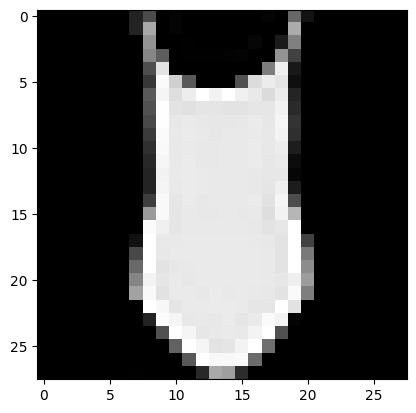

In [56]:
plt.imshow(image.squeeze(), cmap= "gray")

In [57]:
# Passing tensor through the model

model_2(image.unsqueeze(dim= 0).to(device))

tensor([[ 0.0325,  0.0523, -0.0123, -0.0416,  0.0105, -0.0830, -0.0755,  0.0198,
          0.0737,  0.0582]], device='cuda:0', grad_fn=<AddmmBackward0>)

### 7.3 Setup a loss function and optimizer for model_2

In [58]:
from helper_functions import accuracy_fn

loss_fn= nn.CrossEntropyLoss()
optimizer= torch.optim.SGD(params= model_2.parameters(),
                           lr= 0.1)

In [59]:
torch.manual_seed(77)
torch.cuda.manual_seed(77)

from timeit import default_timer as timer

train_time_start_model_2= timer()

epochs= 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---------")
  train_step(model= model_2,
             dataloader= train_dataloader,
             loss_fn= loss_fn,
             optimizer= optimizer,
             accuracy_fn= accuracy_fn,
             device= device)
  test_step(model= model_2,
            dataloader= test_dataloader,
            loss_fn= loss_fn,
            accuracy_fn= accuracy_fn,
            device= device)

train_time_end_model_2= timer()

total_train_time_model_2= print_train_time(start= train_time_start_model_2,
                                             end= train_time_end_model_2,
                                             device= device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.592 | Train acc: 78.69
Test loss: 0.000 | Test acc: 85.00
Epoch: 1
---------
Train loss: 0.343 | Train acc: 87.77
Test loss: 0.000 | Test acc: 88.40
Epoch: 2
---------
Train loss: 0.309 | Train acc: 88.92
Test loss: 0.000 | Test acc: 89.07
Train time on cuda: 37.515 seconds


In [60]:
# Get model results
model_2_results= eval_model(model= model_2,
                            data_loader= test_dataloader,
                            loss_fn= loss_fn,
                            accuracy_fn= accuracy_fn,
                            device= device)

model_2_results

{'model_name': 'FashionMNISTV2',
 'model_loss': 0.31792929768562317,
 'model_acc': 88.74800319488818}

## 8. Compare the model resutls and training time

In [61]:
import pandas as pd

compare_results= pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTV0,0.477698,82.907348
1,FashionMNISTV1,1.120559,58.736022
2,FashionMNISTV2,0.317929,88.748003


In [62]:
# Add training time
compare_results["training time"]= [total_train_time_model_0, total_train_time_model_1, total_train_time_model_2]
compare_results

,model_name,model_loss,model_acc,training time
0,FashionMNISTV0,0.477698,82.907348,28.051725
1,FashionMNISTV1,1.120559,58.736022,32.296635
2,FashionMNISTV2,0.317929,88.748003,37.514690


Text(0, 0.5, 'model')

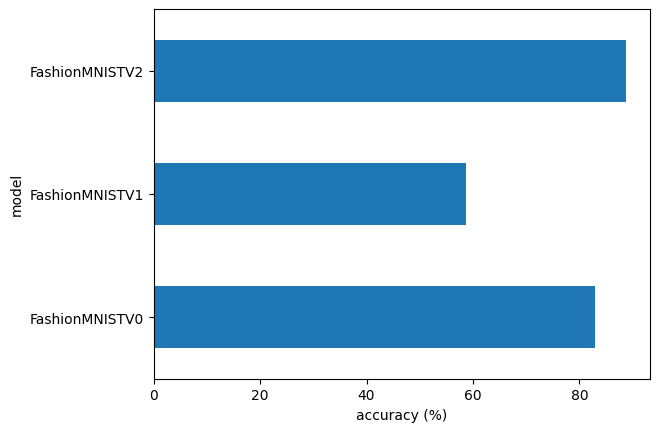

In [63]:
# visualize the model results
compare_results.set_index("model_name")["model_acc"].plot(kind= "barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")

## 9. Make and evaluate random predictions with model 2

In [64]:
def make_predictions(model: nn.Module,
                     data: list,
                     device: torch.device= device):
  pred_probs= []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      # prepare the sample (add batch dimension and pass it to the target device)
      sample= torch.unsqueeze(sample, dim= 0).to(device)

      # forward pass (model outputs raw logits)
      pred_logits= model(sample)

      # Get prediction probability (logits -> prediction probability)
      pred_prob= torch.softmax(pred_logits.squeeze(), dim= 0)

      # Get pred_prob off the GPU for further calculations
      pred_probs.append(pred_prob.cpu())

  # Stack the pred_probs to turn list into a tensor
  return torch.stack(pred_probs)

In [65]:
img, label= test_data[0][:10]
img.shape, label

(torch.Size([1, 28, 28]), 9)

In [66]:
import random
# random.seed(77)
test_samples= []
test_labels= []

for sample, label in random.sample(list(test_data), k= 9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Shirt')

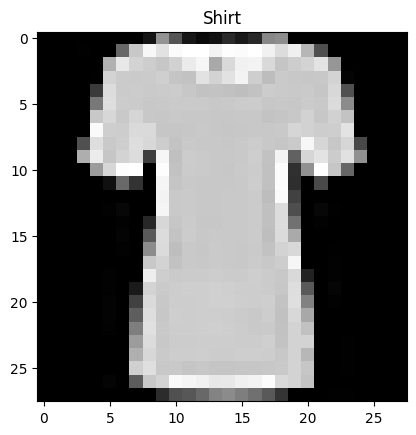

In [67]:
plt.imshow(test_samples[0].squeeze(), cmap= "grey")
plt.title(class_names[test_labels[0]])

In [68]:
# Make predictions
pred_probs= make_predictions(model= model_2,
                             data= test_samples)
pred_probs[: 1]

tensor([[9.6915e-01, 1.8355e-06, 7.3367e-05, 9.1608e-04, 3.0011e-07, 9.3424e-08,
         2.9858e-02, 4.5544e-08, 2.6713e-06, 1.8448e-07]])

In [69]:
# Convert pred probs into labels
pred_classes= pred_probs.argmax(dim= 1)
pred_classes

tensor([0, 2, 4, 7, 9, 1, 1, 8, 0])

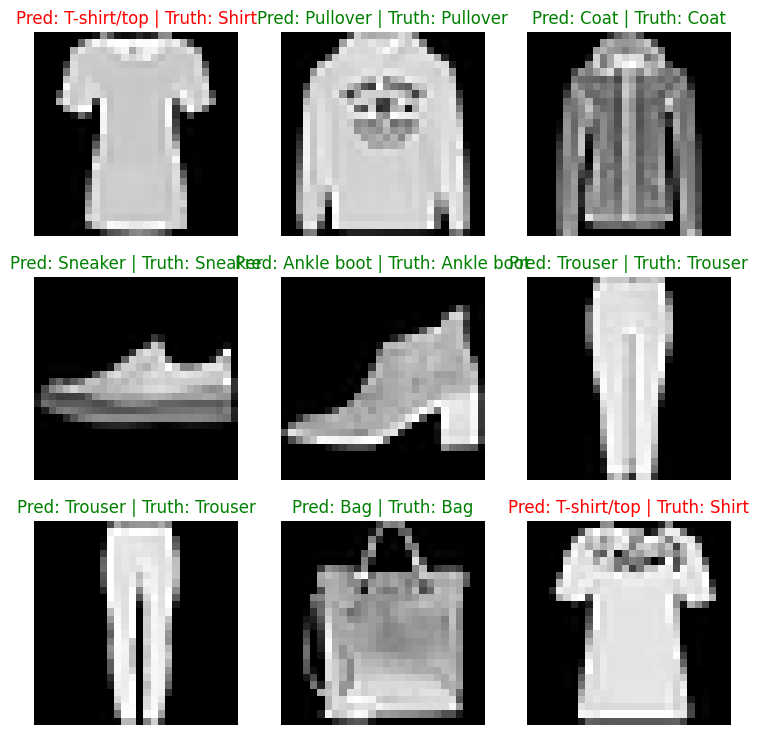

In [70]:
# Plot predictions
plt.figure(figsize= (9, 9))
nrows= 3
ncols= 3
for i, sample in enumerate(test_samples):
  # Create subplot
  plt.subplot(nrows, ncols, i+ 1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap= "grey")

  # Find the prediction
  pred_label= class_names[pred_classes[i]]

  # Get the truth label
  truth_label= class_names[test_labels[i]]

  # Create a title for the plot
  title_test= f"Pred: {pred_label} | Truth: {truth_label}"

  # Check for equality between pred and truth and change color of the title text
  if pred_label== truth_label:
    plt.title(title_test, c= "g")
  else:
    plt.title(title_test, c="r")

  plt.axis(False)

## 10. Making a confusion matrix for further prediction evaluation

1. Make predictions with the trained model on the test dataset
2. Make a confusion matrix with `torchmetrics.ConfusionMatrix`
3. Plot the confusion matrix using `mlxtend.plotting.plot_confusion_matrix`

In [71]:
# Make predictions on entire test datast
y_preds= []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc= "Making predictions..."):
    X, y= X.to(device), y.to(device)
    y_logit= model_2(X)
    y_pred= torch.softmax(y_logit.squeeze(), dim= 0).argmax(dim= 1)
    y_preds.append(y_pred.cpu())

# print(y_preds)
y_pred_tensor= torch.cat(y_preds)
y_pred_tensor

Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1,  ..., 8, 1, 2])

In [72]:
y_pred_tensor.shape

torch.Size([10000])

In [75]:
!pip install -q torchmetrics

from torchmetrics import ConfusionMatrix
import mlxtend
from mlxtend.plotting import plot_confusion_matrix

mlxtend.__version__

'0.23.4'

In [77]:
confmat= ConfusionMatrix(task="multiclass", num_classes= len(class_names))
confmat_tensor= confmat(preds= y_pred_tensor,
                        target= test_data.targets)

confmat_tensor

tensor([[611,   5,  36,  83,  16,   1, 241,   0,   7,   0],
        [  9, 888,   6,  73,  16,   0,   4,   0,   3,   1],
        [  8,   3, 800,  18, 106,   0,  61,   0,   4,   0],
        [ 23,  11,  13, 869,  46,   1,  32,   1,   4,   0],
        [  5,   4, 102,  34, 767,   0,  84,   0,   4,   0],
        [  8,   2,   2,  16,   2, 797,   8,  79,  69,  17],
        [ 69,   4, 105,  72, 100,   0, 634,   0,  16,   0],
        [  1,   1,   0,   3,   0,  23,   0, 924,  11,  37],
        [ 15,   4,   8,  18,  16,   6,  13,   8, 908,   4],
        [  3,   1,   0,   4,   1,  30,  17, 123,  15, 806]])

Text(0.5, 1.0, 'Confusion matrix')

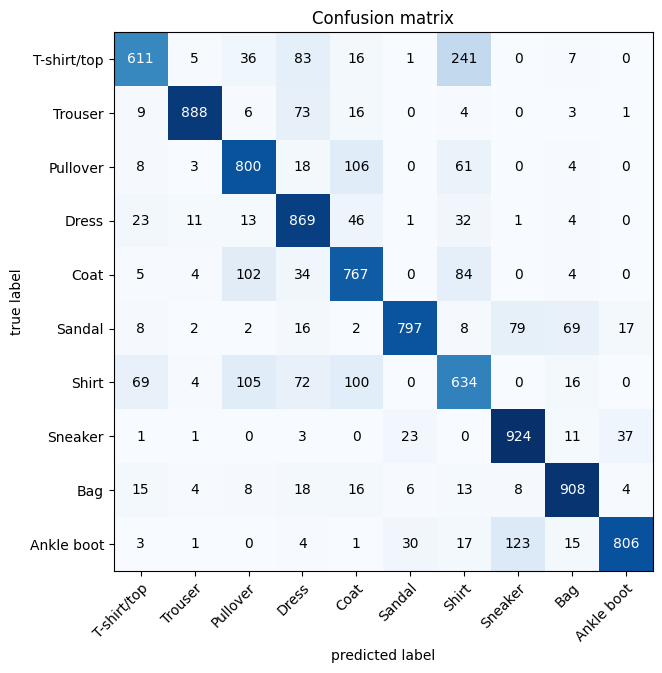

In [79]:
fig, ax= plot_confusion_matrix(
    conf_mat= confmat_tensor.numpy(),   # matplotlib takes in lists instead of tensors
    class_names= class_names,
    figsize= (10, 7)
)
plt.title("Confusion matrix")

## 11. Save the model

In [81]:
from pathlib import Path

MODEL_PATH= Path("models")
MODEL_PATH.mkdir(parents= True,
                 exist_ok= True)

MODEL_NAME= "03_pytorch_computer_vision.pth"
MODEL_SAVE_PATH= MODEL_PATH/ MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")

torch.save(obj= model_2.state_dict(),
           f= MODEL_SAVE_PATH)

Saving model to: models/03_pytorch_computer_vision.pth


In [82]:
torch.manual_seed(77)

loaded_model_2= FashionMNISTV2(input_shape= 1,
                               hidden_units= 10,
                               output_shape= len(class_names))

loaded_model_2.load_state_dict(torch.load(f= MODEL_SAVE_PATH))

loaded_model_2.to(device)

FashionMNISTV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [83]:
model_2_results

{'model_name': 'FashionMNISTV2',
 'model_loss': 0.31792929768562317,
 'model_acc': 88.74800319488818}

In [88]:
loaded_model_2_results= eval_model(model= loaded_model_2,
                                   data_loader= test_dataloader,
                                   loss_fn= loss_fn,
                                   accuracy_fn= accuracy_fn,
                                   device= device)
loaded_model_2_results

{'model_name': 'FashionMNISTV2',
 'model_loss': 0.31792929768562317,
 'model_acc': 88.74800319488818}

In [90]:
# Check if model results are close to each other
torch.isclose(torch.tensor(model_2_results["model_loss"]),
              torch.tensor(loaded_model_2_results["model_loss"]),
              atol= 1e-02)    # tolerence level (optional)

tensor(True)